In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.13.10 (tags/v3.13.10:4fd8843, Dec  2 2025, 15:08:18) [MSC v.1944 64 bit (AMD64)]

Python executable:
C:\Users\Rishika Reddy\AppData\Local\Programs\Python\Python313\python.exe


In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [3]:
import os

os.makedirs("Flickr8k", exist_ok=True)

print("Flickr8k folder created!")

Flickr8k folder created!


In [4]:
import urllib.request

caption_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_text.zip"

urllib.request.urlretrieve(
    caption_url,
    "Flickr8k_text.zip"
)

print("Caption dataset downloaded successfully!")

Caption dataset downloaded successfully!


In [5]:
import zipfile
import os

with zipfile.ZipFile("Flickr8k_text.zip", "r") as zip_ref:
    zip_ref.extractall("Flickr8k")

print("Captions extracted successfully!")

Captions extracted successfully!


In [6]:
print(os.listdir("Flickr8k"))

['CrowdFlowerAnnotations.txt', 'ExpertAnnotations.txt', 'Flickr8k.lemma.token.txt', 'Flickr8k.token.txt', 'Flickr_8k.devImages.txt', 'Flickr_8k.testImages.txt', 'Flickr_8k.trainImages.txt', 'readme.txt', '__MACOSX']


In [7]:
import os

caption_file = "Flickr8k/Flickr8k.token.txt"

captions = {}

with open(caption_file, "r", encoding="utf-8") as file:
    for line in file:
        line = line.strip()

        image_name, caption = line.split("\t")

        # Remove #0, #1, etc. from image name
        image_name = image_name.split("#")[0]

        # Clean caption
        caption = caption.lower()

        # Add start and end tokens
        caption = "startseq " + caption + " endseq"

        if image_name not in captions:
            captions[image_name] = []

        captions[image_name].append(caption)

print("Number of images:", len(captions))
print("Total captions:", sum(len(v) for v in captions.values()))

Number of images: 8092
Total captions: 40460


In [8]:
sample_image = list(captions.keys())[0]

print("Image:", sample_image)
print("\nCaptions:")

for caption in captions[sample_image]:
    print("-", caption)

Image: 1000268201_693b08cb0e.jpg

Captions:
- startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
- startseq a girl going into a wooden building . endseq
- startseq a little girl climbing into a wooden playhouse . endseq
- startseq a little girl climbing the stairs to her playhouse . endseq
- startseq a little girl in a pink dress going into a wooden cabin . endseq


In [9]:
import urllib.request

image_url = "https://github.com/jbrownlee/Datasets/releases/download/Flickr8k/Flickr8k_Dataset.zip"

print("Starting image download...")
print("This is a large file, so please wait...")

urllib.request.urlretrieve(
    image_url,
    "Flickr8k_Dataset.zip"
)

print("Image dataset downloaded successfully!")

Starting image download...
This is a large file, so please wait...
Image dataset downloaded successfully!


In [10]:
import zipfile
import os

print("Extracting Flickr8k images...")
print("Please wait...")

with zipfile.ZipFile("Flickr8k_Dataset.zip", "r") as zip_ref:
    zip_ref.extractall(".")

print("Images extracted successfully!")

Extracting Flickr8k images...
Please wait...
Images extracted successfully!


In [11]:
import os

print(os.listdir("."))

['.android', '.antigravity-ide', '.cache', '.codeium', '.conda', '.copilot', '.cursor', '.devin', '.eclipse', '.gemini', '.git', '.gitconfig', '.idlerc', '.ipynb_checkpoints', '.ipython', '.jupyter', '.keras', '.m2', '.ms-ad', '.node_repl_history', '.nuget', '.p2', '.redhat', '.ssh', '.streamlit', '.templateengine', '.vscode', '.vscode-shared', 'Anti ragging.html', 'AppData', 'Application Data', 'Camera', 'CAnaconda3', 'CascadeProjects', 'Contacts', 'Cookies', 'CrossDevice', 'Desktop', 'devops', 'Documents', 'Downloads', 'eclipse', 'eclipse-workspace', 'EDP WEEK5&6.ipynb', 'EDP_Week5.ipynb', 'exp2.py', 'Favorites', 'Flicker8k_Dataset', 'Flickr8k', 'Flickr8k_Dataset.zip', 'Flickr8k_text.zip', 'harikakka-birthday', 'helloworld', 'Image_Caption_Generator_Week5.ipynb', 'Law And Order.html', 'Links', 'Local Settings', 'Microsoft', 'minimax_game.json', 'Music', 'My Documents', 'MyAlbums', 'NetHood', 'New folder', 'New folder (2)', 'NTUSER.DAT', 'ntuser.dat.LOG1', 'ntuser.dat.LOG2', 'NTUSER.D

In [12]:
IMAGE_FOLDER = "Flickr8k_Dataset"

print("Image folder:", IMAGE_FOLDER)
print("Number of files:", len(os.listdir(IMAGE_FOLDER)))

Image folder: Flickr8k_Dataset


FileNotFoundError: [WinError 3] The system cannot find the path specified: 'Flickr8k_Dataset'

In [13]:
import os

print("Folders in current location:\n")

for item in os.listdir("."):
    if os.path.isdir(item):
        print(item)

Folders in current location:

.android
.antigravity-ide
.cache
.codeium
.conda
.copilot
.cursor
.devin
.eclipse
.gemini
.git
.idlerc
.ipynb_checkpoints
.ipython
.jupyter
.keras
.m2
.ms-ad
.nuget
.p2
.redhat
.ssh
.streamlit
.templateengine
.vscode
.vscode-shared
AppData
Application Data
Camera
CAnaconda3
CascadeProjects
Contacts
Cookies
CrossDevice
Desktop
devops
Documents
Downloads
eclipse
eclipse-workspace
Favorites
Flicker8k_Dataset
Flickr8k
harikakka-birthday
helloworld
Links
Local Settings
Microsoft
Music
My Documents
MyAlbums
NetHood
New folder
New folder (2)
OneDrive
PrintHood
Recent
Saved Games
Searches
SendTo
source
Start Menu
Templates
tomcat_pproject
Videos
WPS Cloud Files
__MACOSX


In [14]:
import os

for root, dirs, files in os.walk("."):
    jpg_files = [f for f in files if f.lower().endswith(".jpg")]
    
    if len(jpg_files) > 10:
        print("IMAGE FOLDER FOUND:")
        print(root)
        print("Number of images:", len(jpg_files))
        break

IMAGE FOLDER FOUND:
.\.gemini\antigravity-ide\browser_recordings\fb9cec0c-7a6d-4dc6-9ded-d302e430a5bd
Number of images: 3518


In [15]:
import os

print("Flickr8k_Dataset exists:",
      os.path.exists("Flickr8k_Dataset"))

if os.path.exists("Flickr8k_Dataset"):
    files = os.listdir("Flickr8k_Dataset")
    jpg_files = [f for f in files if f.lower().endswith(".jpg")]

    print("Files inside Flickr8k_Dataset:", len(files))
    print("JPG images:", len(jpg_files))

    if jpg_files:
        print("\nFirst 5 images:")
        print(jpg_files[:5])

Flickr8k_Dataset exists: False


In [16]:
import zipfile
import os

zip_file = "Flickr8k_Dataset.zip"

print("ZIP file exists:", os.path.exists(zip_file))

if os.path.exists(zip_file):
    with zipfile.ZipFile(zip_file, "r") as z:
        print("Number of files in ZIP:", len(z.namelist()))
        print("\nFirst 10 files:")
        for name in z.namelist()[:10]:
            print(name)

ZIP file exists: True
Number of files in ZIP: 16186

First 10 files:
Flicker8k_Dataset/
Flicker8k_Dataset/1000268201_693b08cb0e.jpg
__MACOSX/
__MACOSX/Flicker8k_Dataset/
__MACOSX/Flicker8k_Dataset/._1000268201_693b08cb0e.jpg
Flicker8k_Dataset/1001773457_577c3a7d70.jpg
__MACOSX/Flicker8k_Dataset/._1001773457_577c3a7d70.jpg
Flicker8k_Dataset/1002674143_1b742ab4b8.jpg
__MACOSX/Flicker8k_Dataset/._1002674143_1b742ab4b8.jpg
Flicker8k_Dataset/1003163366_44323f5815.jpg


In [18]:
import os

zip_path = os.path.abspath("Flickr8k_Dataset.zip")

print("Dataset ZIP location:")
print(zip_path)

print("\nDoes it exist?")
print(os.path.exists(zip_path))

if os.path.exists(zip_path):
    size_gb = os.path.getsize(zip_path) / (1024**3)
    print("\nZIP size:", round(size_gb, 2), "GB")

Dataset ZIP location:
C:\Users\Rishika Reddy\Flickr8k_Dataset.zip

Does it exist?
True

ZIP size: 1.04 GB


In [19]:
import zipfile
import os

zip_path = "Flickr8k_Dataset.zip"
extract_folder = "Flickr8k_Images"

print("Extracting Flickr8k images...")
print("Please wait...")

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_folder)

print("Extraction completed!")

Extracting Flickr8k images...
Please wait...
Extraction completed!


In [20]:
import os

image_folder = "Flickr8k_Images"

print("Image folder exists:", os.path.exists(image_folder))

# Find JPG files, including inside subfolders
jpg_files = []

for root, dirs, files in os.walk(image_folder):
    for file in files:
        if file.lower().endswith(".jpg"):
            jpg_files.append(os.path.join(root, file))

print("Number of JPG images:", len(jpg_files))

print("\nFirst 5 images:")
for image in jpg_files[:5]:
    print(image)

Image folder exists: True
Number of JPG images: 16182

First 5 images:
Flickr8k_Images\Flicker8k_Dataset\1000268201_693b08cb0e.jpg
Flickr8k_Images\Flicker8k_Dataset\1001773457_577c3a7d70.jpg
Flickr8k_Images\Flicker8k_Dataset\1002674143_1b742ab4b8.jpg
Flickr8k_Images\Flicker8k_Dataset\1003163366_44323f5815.jpg
Flickr8k_Images\Flicker8k_Dataset\1007129816_e794419615.jpg


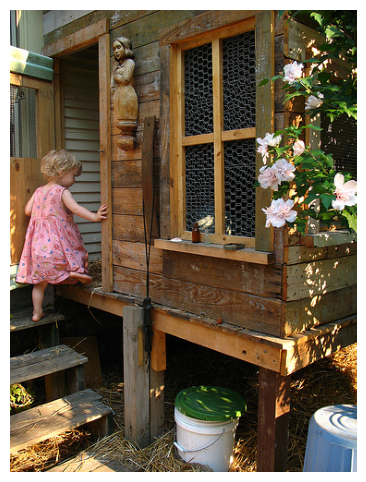

Image: 1000268201_693b08cb0e.jpg

Captions:
- startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
- startseq a girl going into a wooden building . endseq
- startseq a little girl climbing into a wooden playhouse . endseq
- startseq a little girl climbing the stairs to her playhouse . endseq
- startseq a little girl in a pink dress going into a wooden cabin . endseq


In [21]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Take the first Flickr8k image
image_path = jpg_files[0]

# Get only the image filename
image_name = os.path.basename(image_path)

# Display image
img = Image.open(image_path)

plt.figure(figsize=(8, 6))
plt.imshow(img)
plt.axis("off")
plt.show()

# Display its captions
print("Image:", image_name)
print("\nCaptions:")

for caption in captions[image_name]:
    print("-", caption)

In [22]:
from tensorflow.keras.preprocessing.text import Tokenizer

# Collect all captions
all_captions = []

for image_name in captions:
    all_captions.extend(captions[image_name])

# Create tokenizer
tokenizer = Tokenizer()
tokenizer.fit_on_texts(all_captions)

# Vocabulary size
vocab_size = len(tokenizer.word_index) + 1

print("Total captions:", len(all_captions))
print("Vocabulary size:", vocab_size)

Total captions: 40460
Vocabulary size: 8496


In [23]:
max_length = max(
    len(caption.split())
    for caption in all_captions
)

print("Maximum caption length:", max_length)

Maximum caption length: 40


In [24]:
sample_caption = captions[sample_image][0]

print("Original caption:")
print(sample_caption)

print("\nTokenized caption:")

sequence = tokenizer.texts_to_sequences(
    [sample_caption]
)[0]

print(sequence)

Original caption:
startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq

Tokenized caption:
[2, 1, 43, 4, 1, 90, 172, 7, 119, 51, 1, 394, 12, 395, 4, 28, 5159, 670, 3]


In [25]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.models import Model

# Load pretrained InceptionV3
base_model = InceptionV3(
    weights="imagenet",
    include_top=True
)

# Remove the final classification layer
feature_model = Model(
    inputs=base_model.input,
    outputs=base_model.layers[-2].output
)

print("InceptionV3 loaded successfully!")
print("Feature size:", feature_model.output_shape)

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 8s 0us/step
InceptionV3 loaded successfully!
Feature size: (None, 2048)


In [26]:
image_names = list(captions.keys())[:500]

print("Images selected:", len(image_names))

Images selected: 500


In [27]:
import os

# Create a dictionary: filename → full path
image_paths = {}

for root, dirs, files in os.walk("Flickr8k_Images"):
    for file in files:
        if file.lower().endswith(".jpg"):
            image_paths[file] = os.path.join(root, file)

print("Images found:", len(image_paths))

# Check one
print("Example:")
first_image = image_names[0]
print(first_image)
print(image_paths.get(first_image))

Images found: 16182
Example:
1000268201_693b08cb0e.jpg
Flickr8k_Images\Flicker8k_Dataset\1000268201_693b08cb0e.jpg


In [28]:
image_features = {}

print("Starting feature extraction...")
print("Please wait...")

for i, image_name in enumerate(image_names):

    # Get image path
    image_path = image_paths[image_name]

    # Load image
    image = Image.open(image_path).convert("RGB")
    image = image.resize((299, 299))

    # Convert to NumPy array
    image = np.array(image)

    # Add batch dimension
    image = np.expand_dims(image, axis=0)

    # Preprocess for InceptionV3
    image = preprocess_input(image)

    # Extract features
    feature = feature_model.predict(
        image,
        verbose=0
    )

    # Store the 2048 features
    image_features[image_name] = feature[0]

    if (i + 1) % 50 == 0:
        print(f"{i + 1}/500 images processed")

print("Feature extraction completed!")

Starting feature extraction...
Please wait...


NameError: name 'np' is not defined

In [29]:
import numpy as np

In [30]:
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

image_features = {}

print("Starting feature extraction...")
print("Please wait...")

for i, image_name in enumerate(image_names):
    image_path = image_paths[image_name]

    image = Image.open(image_path).convert("RGB")
    image = image.resize((299, 299))

    image = np.array(image)
    image = np.expand_dims(image, axis=0)
    image = preprocess_input(image)

    feature = feature_model.predict(image, verbose=0)

    image_features[image_name] = feature[0]

    if (i + 1) % 50 == 0:
        print(f"{i + 1}/500 images processed")

print("Feature extraction completed!")

Starting feature extraction...
Please wait...
50/500 images processed
100/500 images processed
150/500 images processed
200/500 images processed
250/500 images processed
300/500 images processed
350/500 images processed
400/500 images processed
450/500 images processed
500/500 images processed
Feature extraction completed!


In [31]:
import numpy as np
from PIL import Image
from tensorflow.keras.applications.inception_v3 import preprocess_input

image_features = {}

print("Starting faster feature extraction...")
print("Please wait...")

batch_size = 32

for start in range(0, len(image_names), batch_size):
    
    batch_names = image_names[start:start + batch_size]
    batch_images = []

    for image_name in batch_names:
        image_path = image_paths[image_name]
        
        image = Image.open(image_path).convert("RGB")
        image = image.resize((299, 299))
        image = np.array(image)
        batch_images.append(image)

    batch_images = np.array(batch_images)
    batch_images = preprocess_input(batch_images)

    features = feature_model.predict(batch_images, verbose=0)

    for image_name, feature in zip(batch_names, features):
        image_features[image_name] = feature

    print(f"{min(start + batch_size, len(image_names))}/{len(image_names)} images processed")

print("Feature extraction completed!")

Starting faster feature extraction...
Please wait...
32/500 images processed
64/500 images processed
96/500 images processed
128/500 images processed
160/500 images processed
192/500 images processed
224/500 images processed
256/500 images processed
288/500 images processed
320/500 images processed
352/500 images processed
384/500 images processed
416/500 images processed
448/500 images processed
480/500 images processed
500/500 images processed
Feature extraction completed!


In [32]:
from tensorflow.keras.layers import Input, Dense, LSTM, Embedding, Dropout, Add
from tensorflow.keras.models import Model

# Image input
image_input = Input(shape=(2048,))
image_features_layer = Dropout(0.5)(image_input)
image_features_layer = Dense(256, activation="relu")(image_features_layer)

# Caption input
caption_input = Input(shape=(max_length,))
caption_embedding = Embedding(
    vocab_size,
    256,
    mask_zero=True
)(caption_input)

caption_embedding = Dropout(0.5)(caption_embedding)

# LSTM language model
lstm_output = LSTM(256)(caption_embedding)

# Combine image + text information
combined = Add()([image_features_layer, lstm_output])

combined = Dense(256, activation="relu")(combined)

# Predict next word
output = Dense(vocab_size, activation="softmax")(combined)

# Create model
model = Model(
    inputs=[image_input, caption_input],
    outputs=output
)

# Compile
model.compile(
    loss="sparse_categorical_crossentropy",
    optimizer="adam"
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 40)                │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 2048)              │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 40, 256)           │       2,174,976 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 2048)              │               0 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 40, 256)           │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ not_equal (NotEqual)          │ (None, 40)                │               0 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 256)               │         524,544 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm (LSTM)                   │ (None, 256)               │         525,312 │ dropout_1[0][0],           │
│                               │                           │                 │ not_equal[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ add (Add)                     │ (None, 256)               │               0 │ dense[0][0], lstm[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 256)               │          65,792 │ add[0][0]                  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 8496)              │       2,183,472 │ dense_1[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 5,474,096 (20.88 MB)

 Trainable params: 5,474,096 (20.88 MB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

X_image = []
X_caption = []
Y = []

print("Preparing training data...")

for image_name in image_names:
    feature = image_features[image_name]

    for caption in captions[image_name]:

        sequence = tokenizer.texts_to_sequences([caption])[0]

        for i in range(1, len(sequence)):

            input_sequence = sequence[:i]
            target_word = sequence[i]

            input_sequence = pad_sequences(
                [input_sequence],
                maxlen=max_length,
                padding="pre"
            )[0]

            X_image.append(feature)
            X_caption.append(input_sequence)
            Y.append(target_word)

X_image = np.array(X_image)
X_caption = np.array(X_caption)
Y = np.array(Y)

print("Training data prepared!")
print("Image data shape:", X_image.shape)
print("Caption data shape:", X_caption.shape)
print("Target data shape:", Y.shape)

Preparing training data...
Training data prepared!
Image data shape: (30242, 2048)
Caption data shape: (30242, 40)
Target data shape: (30242,)


In [34]:
print("Starting model training...")

history = model.fit(
    [X_image, X_caption],
    Y,
    batch_size=128,
    epochs=1,
    validation_split=0.1,
    verbose=1
)

print("Training completed!")

Starting model training...
213/213 ━━━━━━━━━━━━━━━━━━━━ 124s 563ms/step - loss: 5.2655 - val_loss: 4.7629
Training completed!


In [35]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

def generate_caption(model, tokenizer, image_feature, max_length):
    caption = "startseq"

    for _ in range(max_length):
        
        sequence = tokenizer.texts_to_sequences([caption])[0]
        
        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="pre"
        )

        prediction = model.predict(
            [image_feature.reshape(1, 2048), sequence],
            verbose=0
        )

        predicted_id = np.argmax(prediction)

        word = tokenizer.index_word.get(predicted_id)

        if word is None:
            break

        caption += " " + word

        if word == "endseq":
            break

    return caption

In [36]:
test_image = image_names[0]

feature = image_features[test_image]

generated_caption = generate_caption(
    model,
    tokenizer,
    feature,
    max_length
)

print("Test Image:", test_image)
print("Generated Caption:")
print(generated_caption)

Test Image: 1000268201_693b08cb0e.jpg
Generated Caption:
startseq a man in a man in a water endseq


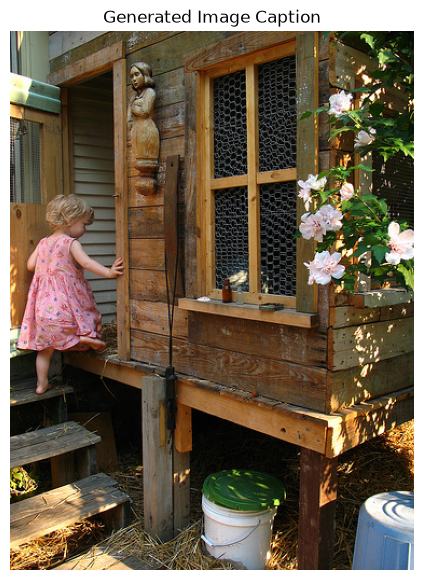

Image: 1000268201_693b08cb0e.jpg
Generated Caption:
startseq a man in a man in a water endseq


In [37]:
import matplotlib.pyplot as plt
from PIL import Image

# Select test image
test_image = image_names[0]

# Get image path
image_path = image_paths[test_image]

# Open image
img = Image.open(image_path)

# Display image
plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Generated Image Caption")
plt.show()

# Display caption
print("Image:", test_image)
print("Generated Caption:")
print(generated_caption)

In [38]:
history = model.fit(
    [X_image, X_caption],
    Y,
    batch_size=128,
    epochs=3,
    validation_split=0.1,
    verbose=1
)

Epoch 1/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 118s 552ms/step - loss: 4.1079 - val_loss: 4.3390
Epoch 2/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 113s 530ms/step - loss: 3.5870 - val_loss: 4.2390
Epoch 3/3
213/213 ━━━━━━━━━━━━━━━━━━━━ 118s 555ms/step - loss: 3.2149 - val_loss: 4.1654


In [39]:
def generate_caption(model, tokenizer, image_feature, max_length):
    caption = "startseq"
    used_words = set()

    for _ in range(max_length):

        sequence = tokenizer.texts_to_sequences([caption])[0]

        sequence = pad_sequences(
            [sequence],
            maxlen=max_length,
            padding="pre"
        )

        prediction = model.predict(
            [image_feature.reshape(1, 2048), sequence],
            verbose=0
        )[0]

        # Try the most probable words until we find one
        # that is not unnecessarily repeated
        candidate_ids = np.argsort(prediction)[::-1]

        predicted_word = None

        for word_id in candidate_ids:
            word = tokenizer.index_word.get(word_id)

            if word is None:
                continue

            if word == "endseq":
                predicted_word = word
                break

            # Avoid immediate repetition
            words = caption.split()

            if len(words) > 1 and word == words[-1]:
                continue

            predicted_word = word
            break

        if predicted_word is None:
            break

        caption += " " + predicted_word

        if predicted_word == "endseq":
            break

    return caption

In [40]:
test_image = image_names[0]

feature = image_features[test_image]

generated_caption = generate_caption(
    model,
    tokenizer,
    feature,
    max_length
)

print("Test Image:", test_image)
print("Generated Caption:")
print(generated_caption)

Test Image: 1000268201_693b08cb0e.jpg
Generated Caption:
startseq a man in a red shirt and a red shirt is sitting on a street endseq


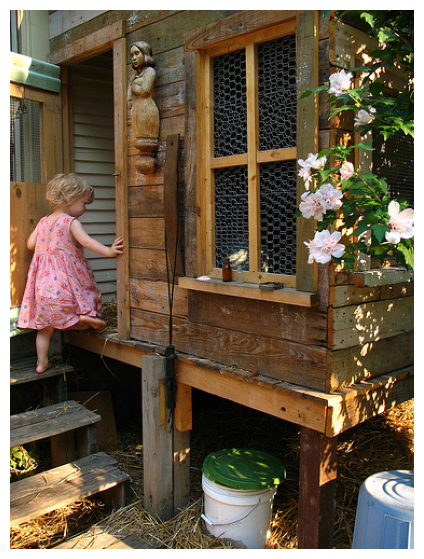

Image used for prediction: 1000268201_693b08cb0e.jpg
Generated Caption:
startseq a man in a red shirt and a red shirt is sitting on a street endseq

Original Flickr8k Captions:
- startseq a child in a pink dress is climbing up a set of stairs in an entry way . endseq
- startseq a girl going into a wooden building . endseq
- startseq a little girl climbing into a wooden playhouse . endseq
- startseq a little girl climbing the stairs to her playhouse . endseq
- startseq a little girl in a pink dress going into a wooden cabin . endseq


In [41]:
# Choose ONE test image
test_image = image_names[0]

# Get its path
image_path = image_paths[test_image]

# Get the feature of THIS exact image
feature = image_features[test_image]

# Generate caption for THIS exact image
generated_caption = generate_caption(
    model,
    tokenizer,
    feature,
    max_length
)

# Display the exact image used
img = Image.open(image_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

print("Image used for prediction:", test_image)
print("Generated Caption:")
print(generated_caption)

# Also show the original Flickr8k captions for comparison
print("\nOriginal Flickr8k Captions:")
for cap in captions[test_image]:
    print("-", cap)

In [42]:
history_more = model.fit(
    [X_image, X_caption],
    Y,
    batch_size=128,
    epochs=5,
    validation_split=0.1,
    verbose=1
)

print("Additional training completed!")

Epoch 1/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 115s 539ms/step - loss: 2.8886 - val_loss: 4.2379
Epoch 2/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 113s 531ms/step - loss: 2.5918 - val_loss: 4.3750
Epoch 3/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 143s 538ms/step - loss: 2.3373 - val_loss: 4.5155
Epoch 4/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 113s 529ms/step - loss: 2.1307 - val_loss: 4.6101
Epoch 5/5
213/213 ━━━━━━━━━━━━━━━━━━━━ 116s 546ms/step - loss: 1.9526 - val_loss: 4.7163
Additional training completed!


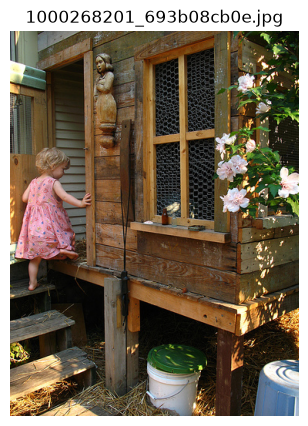

Generated Caption:
startseq a woman in a blue shirt and white shorts is sitting on a wooden cabin endseq
------------------------------------------------------------


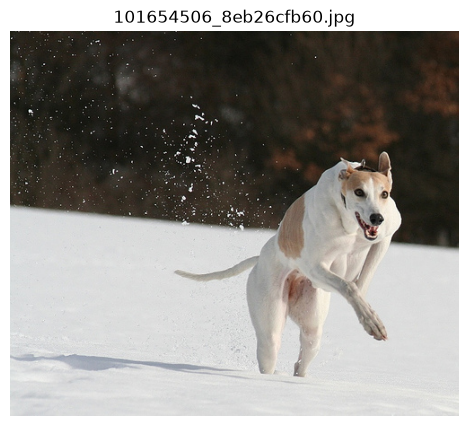

Generated Caption:
startseq a white dog is running through the snow endseq
------------------------------------------------------------


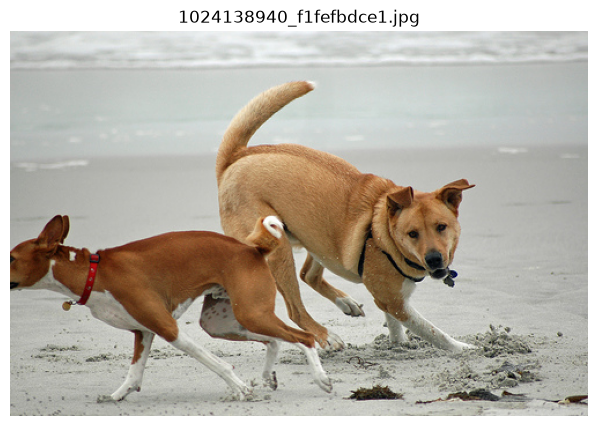

Generated Caption:
startseq two dogs playing on the beach endseq
------------------------------------------------------------


In [43]:
import matplotlib.pyplot as plt
from PIL import Image

test_images = [image_names[0], image_names[10], image_names[20]]

for test_image in test_images:

    feature = image_features[test_image]

    caption = generate_caption(
        model,
        tokenizer,
        feature,
        max_length
    )

    img = Image.open(image_paths[test_image])

    plt.figure(figsize=(8, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(test_image)
    plt.show()

    print("Generated Caption:")
    print(caption)
    print("-" * 60)

In [44]:
import os
print(os.getcwd())

C:\Users\Rishika Reddy


In [45]:
import os

for file in os.listdir():
    if file.endswith(".ipynb"):
        print("Notebook:", os.path.abspath(file))

Notebook: C:\Users\Rishika Reddy\EDP WEEK5&6.ipynb
Notebook: C:\Users\Rishika Reddy\EDP_Week5.ipynb
Notebook: C:\Users\Rishika Reddy\Image_Caption_Generator_Week5.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled1.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled10.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled11.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled12.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled13.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled14.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled15.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled2.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled3.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled4.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled5.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled6.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled7.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled8.ipynb
Notebook: C:\Users\Rishika Reddy\Untitled9.ipynb
Notebook: C:\Users\Rishika Reddy\Week5_Edp